<a href="https://colab.research.google.com/github/xogh5066/keras/blob/master/Ai_Grades_DB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


요약 : **학생들의 AI 활용 능력이 고도화되고 있음에도 불구하고, 이것이 실제 학업 성취도(GPA) 향상으로 직결되지는 않음을 데이터로 확인했다. 이는 AI가 과제를 보조하는 편리한 도구일 수는 있으나, 근본적인 학습 역량을 대체할 수는 없음**


캐글 데이터를 수집하던중 요즘 이슈인 Ai에 대해 조사하다 대학생이 성적 증가폭이 과연 Ai와 관련이 있는가? 에 대해 주제를 잡게되었습니다.

In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/ranaghulamnabi/ai-usage-and-student-academic-performance-analysis")

Skipping, found downloaded files in "./ai-usage-and-student-academic-performance-analysis" (use force=True to force download)


In [ ]:
import pandas as pd
data = pd.read_csv("/content/ai-usage-and-student-academic-performance-analysis/ai_student_impact_dataset (1).csv")

데이터 kaggle 과 collab 연동으로 해당 주제 데이터 연동후 시각화

In [ ]:
data.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


시각화 한 결과 총 16개의 열 ([이름],[시험 중 불안 수준],[번아웃 위험 수준],[기관 정책],[유료 구독 여부],[AI 의존성],[학기말 학점],[학기전 평점],[주요 사용 사례],[프롬포트 엔지니어링 기술],[기술 유지 점수],[학생ID],[도구 다양성],[일반 학습시간],[주간Ai사용시간],[학년]) 으로 구성됨.

데이터 자료가 너무 많아 간소화 ([아이디],[학기전 학점],[주간 Ai사용시간],[Ai도구개수],[유료 구독 여부],[일반 학습시간],[AI의존성],[학기말 학점]) 8개 열으로 데이터 클리닝작업 우선작업

In [ ]:
columns_to_drop = ['Burnout_Risk_Level','Institutional_Policy','Primary_Use_Case','Prompt_Engineering_Skill','Skill_Retention_Score','Year_of_Study','Major_Category','Anxiety_Level_During_Exams']


In [ ]:
data.drop(columns_to_drop, axis=1, inplace=True)

[유료 구독 여부] 데이터 카테고리컬 데이터 -> 넘버 타입 데이터로 변환

In [ ]:
data['Paid_Subscription'] = data['Paid_Subscription'].astype(int)

In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Student_ID               50000 non-null  int64  
 1   Pre_Semester_GPA         50000 non-null  float64
 2   Weekly_GenAI_Hours       50000 non-null  float64
 3   Tool_Diversity           50000 non-null  int64  
 4   Paid_Subscription        50000 non-null  int64  
 5   Traditional_Study_Hours  50000 non-null  float64
 6   Perceived_AI_Dependency  50000 non-null  int64  
 7   Post_Semester_GPA        50000 non-null  float64
dtypes: float64(4), int64(4)
memory usage: 3.1 MB


In [ ]:
data.head()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Post_Semester_GPA
0,100001,2.418,23.31,1,1,8.13,5,2.393
1,100002,3.821,1.12,5,0,16.65,3,3.696
2,100003,3.398,21.26,2,0,10.35,5,3.499
3,100004,3.789,1.82,4,0,15.23,2,4.000
4,100005,3.635,9.29,4,0,12.55,4,3.798


넘버타입 데이터들을 표로 히트맵화 하여 상관계수 도출.

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5]),
 [Text(0.5, 0, 'Student_ID'),
  Text(1.5, 0, 'Pre_Semester_GPA'),
  Text(2.5, 0, 'Weekly_GenAI_Hours'),
  Text(3.5, 0, 'Tool_Diversity'),
  Text(4.5, 0, 'Paid_Subscription'),
  Text(5.5, 0, 'Traditional_Study_Hours'),
  Text(6.5, 0, 'Perceived_AI_Dependency'),
  Text(7.5, 0, 'Post_Semester_GPA')])

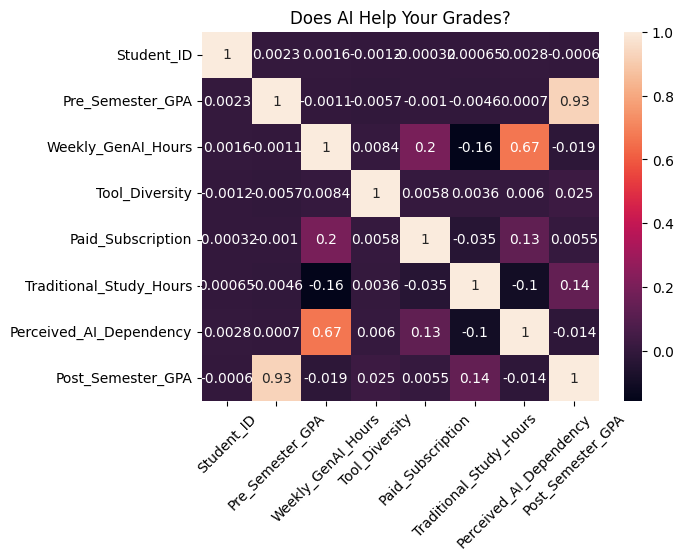

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
data.corr()
sns.heatmap(data.corr(), annot=True)
plt.title("Does AI Help Your Grades?")
plt.xticks(rotation=45)

도출한 결과 데이터로 알 수 있는 결과는

- **주간 AI 사용 시간과 학기 종료후의 학점의 상관관계:** **0.019** (0에 가까움)
- **AI 도구 갯수와 학기 종료후의 학점의 상관관계:** **0.025** (0에 가까움)
- **유료 구독 여부와 학기 종료후의 학점의 상관관계:** **0.0055** (사실상 0)
- **AI 의존성과 학기 종료후의 학점의 상관관계:** **0.014** (사실상 0)

AI를 적게 쓰든 많이 사용하든 돈을 내고 유료버전을 쓰든 안 쓰든 학기 최종 학점에는 유의미한 영향을 주지 않는다.

새롭게 발견하게된 데이터는

- **학기 시작 전 학점 과 학기 종료후의 학점 (0.93) :** 원래 공부를 잘하던 학생이 학기 말에도 잘했을 확률이 매우 높다. AI 도입과 상관없이 기존 학업 역량이 성적을 지배하고 있음
- **일반 공부 시간 과 학기 종료후의 학점 (0.14) :**  수치는 낮지만, AI 관련 변수들보다는 성적과 훨씬 더 긍정적인 관계를 보여줍니다. 여전히 스스로 엉덩이를 붙이고 앉아서 하는 전통적인 공부가 성적 향상에 조금이나마 기여
- **주간 AI 사용 시간 과 AI 의존성 (0.67):** 꽤 높은 양의 상관관계입니다. 당연하게도 AI를 사용하는 시간이 길어질수록 본인이 AI에 의존하고 있다고 느끼는 체감이 올라감.
- **주간 AI 사용 시간 과 일반 공부 시간 (-0.16):** 음수의 수치로 AI를 붙잡고 있는 시간이 늘어날수록 책을 보며 혼자 공부하는 물리적인 시간은 다소 줄어드는 경향

만약 프롬포트 엔지니어링 기술(Prompt_Engineering_Skill)을 포함시킨 히트맵으로 구현한다면?

In [ ]:
columns_to_drop = ['Burnout_Risk_Level','Institutional_Policy','Primary_Use_Case','Skill_Retention_Score','Year_of_Study','Major_Category','Anxiety_Level_During_Exams']


In [ ]:
data.drop(columns_to_drop, axis=1, inplace=True)

In [ ]:
print("변경 전 고유값들:", data['Prompt_Engineering_Skill'].unique())

변경 전 고유값들: ['Beginner' 'Advanced' 'Intermediate']


In [ ]:
data['Paid_Subscription'] = data['Paid_Subscription'].astype(int)
mapping = {
    'Beginner' : 1,
    'Advanced' : 2,
    'Intermediate' : 3
}
data['Prompt_Engineering_Skill'] = data['Prompt_Engineering_Skill'].map(mapping)

In [ ]:
print(data['Prompt_Engineering_Skill'])

0        1
1        2
2        1
3        3
4        2
        ..
49995    1
49996    3
49997    2
49998    3
49999    1
Name: Prompt_Engineering_Skill, Length: 50000, dtype: int64


프롬포트 엔지니어링 능력은 문자열이여서 매핑으로 ( 초보 : 1 중급 :2 고급 : 3 ) 변경후 숫자 타입 데이터로 변경

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Student_ID                50000 non-null  int64  
 1   Pre_Semester_GPA          50000 non-null  float64
 2   Weekly_GenAI_Hours        50000 non-null  float64
 3   Prompt_Engineering_Skill  50000 non-null  int64  
 4   Tool_Diversity            50000 non-null  int64  
 5   Paid_Subscription         50000 non-null  int64  
 6   Traditional_Study_Hours   50000 non-null  float64
 7   Perceived_AI_Dependency   50000 non-null  int64  
 8   Post_Semester_GPA         50000 non-null  float64
dtypes: float64(4), int64(5)
memory usage: 3.4 MB


In [ ]:
data.head()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Post_Semester_GPA
0,100001,2.418,23.31,1,1,1,8.13,5,2.393
1,100002,3.821,1.12,2,5,0,16.65,3,3.696
2,100003,3.398,21.26,1,2,0,10.35,5,3.499
3,100004,3.789,1.82,3,4,0,15.23,2,4.000
4,100005,3.635,9.29,2,4,0,12.55,4,3.798


(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5]),
 [Text(0.5, 0, 'Student_ID'),
  Text(1.5, 0, 'Pre_Semester_GPA'),
  Text(2.5, 0, 'Weekly_GenAI_Hours'),
  Text(3.5, 0, 'Prompt_Engineering_Skill'),
  Text(4.5, 0, 'Tool_Diversity'),
  Text(5.5, 0, 'Paid_Subscription'),
  Text(6.5, 0, 'Traditional_Study_Hours'),
  Text(7.5, 0, 'Perceived_AI_Dependency'),
  Text(8.5, 0, 'Post_Semester_GPA')])

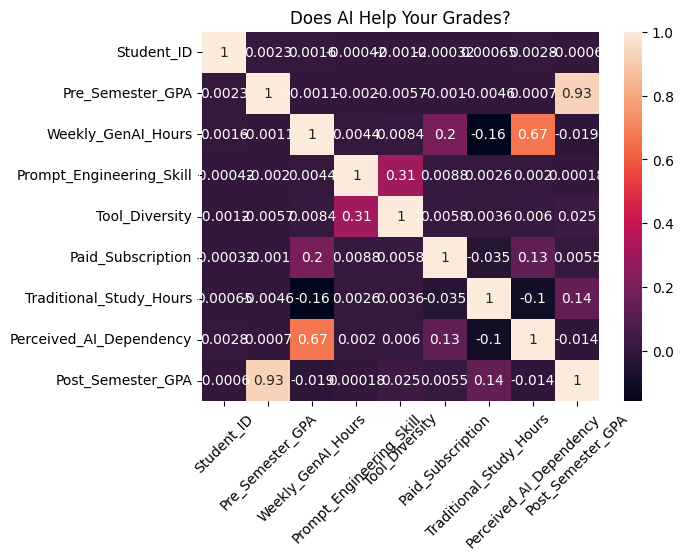

In [ ]:
data.corr()
sns.heatmap(data.corr(), annot=True)
plt.title("Does AI Help Your Grades?")
plt.xticks(rotation=45)

프롬포트 엔지니어링 능력을 추가한 상태에서 히트맵을 도출한 결과 데이터로 알 수 있는 결과는

- **프롬포트 엔지니어링 능력과 학기 종료후의 학점의 상관관계:** 0.00018 (사실상 0)

프롬프트를 다루는 스킬이 뛰어나든(Advanced), 보통이든(Intermediate), 부족하든(Beginner) 최종 성적과는 통계적으로 아무런 관련이 없다.

AI를 얼마나 오래 쓰는지, 얼마나 능숙하게 쓰는지, 얼마나 다양하게 쓰는지와 무관하게, 성적을 결정짓는 핵심 요인은 여전히 **기존 학점(0.93)과 순수한 일반 공부 시간(0.14)**

⇒ 학생들이 AI 활용 능력이 실제 학업 성취도 향상으로 직결되지 않는다.